In [15]:
# ==== CELL 1: Data Retrieval ====
# Read site IDs from text file and retrieve USGS discharge measurements
from dataretrieval import nwis
from IPython.display import display
import pandas as pd
from pathlib import Path

def read_site_ids(file_path):
    """
    Read site IDs from a text file and clean them up.
    Removes 'USGS' prefix and any whitespace.
    """
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Clean up the site IDs: remove 'USGS', strip whitespace, filter empty lines
    site_ids = []
    for line in lines:
        line = line.strip()  # Remove leading/trailing whitespace
        if line:  # Skip empty lines
            # Remove 'USGS' prefix if present (case insensitive)
            if line.upper().startswith('USGS '):
                site_id = line[5:]  # Remove 'USGS ' (5 characters)
            else:
                site_id = line
            site_ids.append(site_id.strip())
    
    return site_ids

# Path to your text file with site IDs
site_file_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\original_data\stream_sb_usgs.txt"

try:
    # Read and clean site IDs
    sites = read_site_ids(site_file_path)
    print(f"Found {len(sites)} site IDs:")
    print(sites[:10])  # Show first 10 sites as preview
    if len(sites) > 10:
        print(f"... and {len(sites) - 10} more sites")
    
    # Retrieve discharge measurements from all sites
    print(f"\nRetrieving discharge measurements from {len(sites)} USGS sites...")
    sb_streams = nwis.get_discharge_measurements(
        sites=sites, 
        start="1800-01-01", 
        end="1979-12-31"
    )
    
    print("Retrieved " + str(len(sb_streams[0])) + " data values.")
    print(f"Data columns: {sb_streams[0].columns.tolist()}")  # Show column names for verification
    display(sb_streams[0].head())  # Show first few rows instead of entire dataframe
    
    # Create output directory if it doesn't exist
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    # Save to CSV
    csv_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv"
    sb_streams[0].to_csv(csv_path, index=False)
    print(f"Saved {len(sb_streams[0]):,} streamflow measurements to: {csv_path}")
    
    # Verify the file was written successfully
    if Path(csv_path).exists():
        file_size = Path(csv_path).stat().st_size
        print(f"File successfully written. Size: {file_size:,} bytes")
    else:
        print("WARNING: CSV file was not created successfully")
    
except FileNotFoundError:
    print(f"Error: Could not find the file '{site_file_path}'")
    print("Please update the 'site_file_path' variable with the correct path to your text file.")
except Exception as e:
    print(f"An error occurred: {e}")
    import traceback
    traceback.print_exc()

print("=== DATA RETRIEVAL COMPLETE ===")
print("You can now run the processing cell...")

# ==== CELL 2: Data Processing ====
print("\n=== PROCESSING STREAMFLOW NWIS DATA ===")

import pandas as pd
from pathlib import Path
import numpy as np

# Load the streamflow CSV data
csv_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv"

try:
    # Check if file exists before trying to read it
    if not Path(csv_path).exists():
        raise FileNotFoundError(f"CSV file not found at {csv_path}")
    
    # Load the streamflow measurements
    sb_streamflow = pd.read_csv(csv_path)
    print(f"Loaded {len(sb_streamflow):,} streamflow measurements")
    
    # Display basic info about the data
    print(f"Columns: {sb_streamflow.columns.tolist()}")
    
    # Check if measurement_dt column exists
    if 'measurement_dt' not in sb_streamflow.columns:
        print("Available columns:", sb_streamflow.columns.tolist())
        raise KeyError("Column 'measurement_dt' not found in the data. Please check column names.")
    
    print(f"Date range in measurement_dt: {sb_streamflow['measurement_dt'].min()} to {sb_streamflow['measurement_dt'].max()}")
    
    # Convert measurement_dt to datetime and extract year
    # Handle mixed date formats: M/D/YYYY and M/D/YYYY HH:MM
    print("Converting dates to datetime format...")
    
    # Custom function to handle the specific date formats
    def parse_mixed_dates(date_str):
        if pd.isna(date_str):
            return pd.NaT
        
        date_str = str(date_str).strip()
        
        # Try format 1: M/D/YYYY HH:MM (e.g., "2/19/1942 23:00")
        try:
            return pd.to_datetime(date_str, format='%m/%d/%Y %H:%M')
        except:
            pass
        
        # Try format 2: M/D/YYYY (e.g., "1/14/1942")
        try:
            return pd.to_datetime(date_str, format='%m/%d/%Y')
        except:
            pass
        
        # Try pandas default parsing as fallback
        try:
            return pd.to_datetime(date_str)
        except:
            return pd.NaT
    
    # Apply the custom parsing function
    sb_streamflow['measurement_dt'] = sb_streamflow['measurement_dt'].apply(parse_mixed_dates)
    sb_streamflow['year'] = sb_streamflow['measurement_dt'].dt.year
    
    # Check for any failed conversions
    failed_conversions = sb_streamflow['measurement_dt'].isna().sum()
    if failed_conversions > 0:
        print(f"Warning: {failed_conversions} dates could not be parsed")
        # Show some examples of failed conversions
        failed_dates = sb_streamflow[sb_streamflow['measurement_dt'].isna()]['measurement_dt'].head()
        if not failed_dates.empty:
            print("Examples of failed date conversions:", failed_dates.tolist())
    else:
        print("All dates parsed successfully")
    
    # Remove rows with failed date conversions for the analysis
    sb_streamflow_clean = sb_streamflow.dropna(subset=['measurement_dt', 'year'])
    if len(sb_streamflow_clean) < len(sb_streamflow):
        print(f"Removed {len(sb_streamflow) - len(sb_streamflow_clean)} rows with invalid dates")
        sb_streamflow = sb_streamflow_clean
    
    print(f"Year range: {sb_streamflow['year'].min()} to {sb_streamflow['year'].max()}")
    print(f"Unique sites: {sb_streamflow['site_no'].nunique()}")
    
    # ==== Summary 1: Each unique site ID with start year, end year, and total measurements ====
    print("\n=== CREATING SITE SUMMARY (Start Year, End Year, and Total Measurements) ===")
    
    site_summary = sb_streamflow.groupby('site_no').agg({
        'year': ['min', 'max'],  # First/earliest year and last/latest year
        'measurement_dt': 'count'  # Total number of measurements
    }).reset_index()
    
    # Flatten the multi-level column names
    site_summary.columns = ['site_no', 'start_year', 'end_year', 'total_measurements']
    
    # Calculate the span of years for each site
    site_summary['year_span'] = site_summary['end_year'] - site_summary['start_year'] + 1
    
    # Sort by start year then site number
    site_summary = site_summary.sort_values(['start_year', 'site_no'])
    
    print(f"Created summary for {len(site_summary):,} unique sites")
    print("Sample of site summary with start and end years:")
    print(site_summary.head())
    
    # Save summary 1
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    
    summary1_path = output_dir / "sb_streamflow_sites_start_end_years.csv"
    site_summary.to_csv(summary1_path, index=False)
    print(f"Saved site summary with start/end years: {summary1_path}")
    
    # ==== Summary 2: Each unique site ID and each unique year it has measurements ====
    print("\n=== CREATING SITE-YEAR SUMMARY (All Years) ===")
    
    # Get unique combinations of site_no and year, with measurement count per year
    site_year_summary = sb_streamflow.groupby(['site_no', 'year']).agg({
        'measurement_dt': 'count'  # Number of measurements in this year
    }).reset_index()
    
    # Rename column for clarity
    site_year_summary.columns = ['site_no', 'year', 'measurements_in_year']
    
    # Sort by site number then year
    site_year_summary = site_year_summary.sort_values(['site_no', 'year'])
    
    print(f"Created site-year summary with {len(site_year_summary):,} site-year combinations")
    print("Sample of site-year summary:")
    print(site_year_summary.head(10))
    
    # Save summary 2
    summary2_path = output_dir / "sb_streamflow_sites_all_years.csv"
    site_year_summary.to_csv(summary2_path, index=False)
    print(f"Saved site-year summary: {summary2_path}")
    
    # ==== Additional Analysis ====
    print("\n=== ADDITIONAL ANALYSIS ===")
    
    print("Site measurement statistics:")
    measurement_stats = site_summary['total_measurements'].describe()
    print(measurement_stats)
    
    print(f"\nYear span statistics:")
    span_stats = site_summary['year_span'].describe()
    print(span_stats)
    
    print(f"\nDecade distribution of start years:")
    decade_counts = site_summary['decade_start'].value_counts().sort_index()
    print(decade_counts)
    
    print(f"\nSites with most measurements:")
    top_sites = site_summary.nlargest(5, 'total_measurements')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span']]
    print(top_sites)
    
    print(f"\nEarliest starting sites:")
    earliest_sites = site_summary.nsmallest(5, 'start_year')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span']]
    print(earliest_sites)
    
    print(f"\nSites with longest monitoring periods:")
    longest_span = site_summary.nlargest(5, 'year_span')[['site_no', 'start_year', 'end_year', 'total_measurements', 'year_span']]
    print(longest_span)
    
    # ==== Create a visualization-ready summary for the decadal analysis ====
    print("\n=== CREATING DECADE SUMMARY FOR MAPPING ===")
    
    # Add decade to site summary for mapping
    site_mapping_summary = site_summary.copy()
    site_mapping_summary['decade'] = site_mapping_summary['decade_start']  # Use decade_start for backward compatibility
    
    # For mapping, we'll need coordinates - but those will come from the site metadata
    # This summary can be merged with site location data later
    
    summary3_path = output_dir / "sb_streamflow_sites_for_mapping.csv"
    site_mapping_summary.to_csv(summary3_path, index=False)
    print(f"Saved mapping summary: {summary3_path}")
    
    print(f"\n=== SUMMARY FILES CREATED ===")
    print(f"1. Site start/end years: {summary1_path}")
    print(f"2. Site-year combinations: {summary2_path}")
    print(f"3. Mapping ready: {summary3_path}")

except FileNotFoundError:
    print(f"ERROR: Could not find the streamflow CSV file at: {csv_path}")
    print("Make sure you've run the data retrieval cell first and that it completed successfully.")
    print("Check that the CSV file was actually created in the expected location.")
except KeyError as e:
    print(f"ERROR: Missing expected column in the data: {e}")
    print("The data structure may have changed. Check the column names in your CSV file.")
except Exception as e:
    print(f"ERROR processing data: {e}")
    print("Check that your CSV file has the expected columns (site_no, measurement_dt, etc.)")
    import traceback
    traceback.print_exc()

Found 83 site IDs:
['11119500', '11119530', '11119660', '11119700', '11119745', '11119750', '11119760', '11119770', '11119780', '11119900']
... and 73 more sites

Retrieving discharge measurements from 83 USGS sites...
Retrieved 1948 data values.
Data columns: ['agency_cd', 'site_no', 'measurement_nu', 'measurement_dt', 'tz_cd', 'q_meas_used_fg', 'party_nm', 'site_visit_coll_agency_cd', 'gage_height_va', 'discharge_va', 'measured_rating_diff', 'gage_va_change', 'gage_va_time', 'control_type_cd', 'discharge_cd']


,agency_cd,site_no,measurement_nu,measurement_dt,tz_cd,q_meas_used_fg,party_nm,site_visit_coll_agency_cd,gage_height_va,discharge_va,measured_rating_diff,gage_va_change,gage_va_time,control_type_cd,discharge_cd
0,USGS,11119500,1,1940-12-31,NaN,Yes,UNK,USGS,2.02,0.25,Good,0.00,0.2,NaN,NONE
1,USGS,11119500,2,1941-01-07,NaN,Yes,UNK,USGS,2.49,13.40,Unspecified,0.00,0.4,NaN,NONE
2,USGS,11119500,3,1941-01-08,NaN,Yes,UNK,USGS,2.38,8.20,Good,0.00,0.3,NaN,NONE
3,USGS,11119500,4,1941-01-09,NaN,Yes,UNK,USGS,2.34,5.50,Unspecified,0.00,0.3,NaN,NONE
4,USGS,11119500,5,1941-01-22,NaN,Yes,UNK,USGS,2.39,8.70,Good,-0.01,0.3,NaN,NONE


Saved 1,948 streamflow measurements to: C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\sb_streamflow_usgs_1800_1979.csv
File successfully written. Size: 148,193 bytes
=== DATA RETRIEVAL COMPLETE ===
You can now run the processing cell...

=== PROCESSING STREAMFLOW NWIS DATA ===
Loaded 1,948 streamflow measurements
Columns: ['agency_cd', 'site_no', 'measurement_nu', 'measurement_dt', 'tz_cd', 'q_meas_used_fg', 'party_nm', 'site_visit_coll_agency_cd', 'gage_height_va', 'discharge_va', 'measured_rating_diff', 'gage_va_change', 'gage_va_time', 'control_type_cd', 'discharge_cd']
Date range in measurement_dt: 1940-12-31 to 1979-12-26
Converting dates to datetime format...
All dates parsed successfully
Year range: 1940 to 1979
Unique sites: 21

=== CREATING SITE SUMMARY (Start Year, End Year, and Total Measurements) ===
Created summary for 21 unique sites
Sample of site summary with start and end years:
     site_no  start_year  end_year  total_measurements  year_span
0 

In [12]:
# ==== FILTER HISTORICAL SITES FOR SANTA YNEZ RIVER ====
print("=== FILTERING FOR SANTA YNEZ RIVER SITES ===")

import re
import os
from matplotlib.lines import Line2D

# First, let's examine what columns we have in historical_streams
print("Available columns in historical_streams:")
print(list(historical_streams.columns))
print(f"\nTotal historical stream sites: {len(historical_streams)}")

# Look for columns that might contain location or water source information
location_columns = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['location', 'name', 'source', 'station', 'site'])]
print(f"\nPotential location/name columns: {location_columns}")

# Create a function to search for Santa Ynez River variations
def contains_santa_ynez(text):
    """
    Check if text contains Santa Ynez River or variations
    Case insensitive search for various spellings
    """
    try:
        # Handle various data types that might be in the columns
        if text is None:
            return False
        if hasattr(text, '__len__') and not isinstance(text, str):
            # Handle arrays, lists, etc. - convert to string
            text_str = str(text).lower()
        elif pd.isna(text):
            return False
        elif text == '':
            return False
        else:
            text_str = str(text).lower()
        
        # Define patterns for Santa Ynez River variations
        patterns = [
            r'santa\s+ynez\s+r',  # Santa Ynez R (river abbreviated)
            r'santa\s+ynez\s+river',  # Santa Ynez River
            r'santa\s+inez\s+r',  # Alternative spelling: Santa Inez
            r'santa\s+inez\s+river',
            r'sta\s+ynez',  # Abbreviated Santa
            r'st\s+ynez',   # Another abbreviation
            r'santa\s+yanez', # Alternative spelling
            r'sante\s+ynez', # Misspelling
        ]
        
        for pattern in patterns:
            if re.search(pattern, text_str):
                return True
        return False
    except Exception as e:
        # If any error occurs, return False and continue
        return False

# Search through all potential columns (excluding problematic ones)
santa_ynez_sites = pd.DataFrame()
search_results = {}

# Define columns to skip
skip_columns = ['keyterms']

for col in historical_streams.columns:
    if col in skip_columns:
        print(f"Skipping column '{col}' (known to cause issues)")
        continue
        
    if historical_streams[col].dtype == 'object':  # Only search text columns
        try:
            matches = historical_streams[historical_streams[col].apply(contains_santa_ynez)]
            if len(matches) > 0:
                search_results[col] = len(matches)
                print(f"\nFound {len(matches)} matches in column '{col}'")
                # Show some example values
                examples = matches[col].unique()[:5]
                print(f"Examples: {list(examples)}")
        except Exception as e:
            print(f"Error searching column '{col}': {e}")
            continue

# Combine all matches (remove duplicates by index)
all_matches_indices = set()
for col in historical_streams.columns:
    if col in skip_columns:
        continue
        
    if historical_streams[col].dtype == 'object':
        try:
            matches_idx = historical_streams[historical_streams[col].apply(contains_santa_ynez)].index
            all_matches_indices.update(matches_idx)
        except Exception as e:
            print(f"Error processing column '{col}': {e}")
            continue

# Get all Santa Ynez sites
santa_ynez_sites = historical_streams.loc[list(all_matches_indices)].copy()

print(f"\n=== SANTA YNEZ RIVER SITES FOUND ===")
print(f"Total Santa Ynez River historical sites: {len(santa_ynez_sites)}")

# ==== LOAD HUC8 WATERSHED FOR SPATIAL FILTERING ====
print(f"\n=== LOADING SANTA YNEZ WATERSHED BOUNDARY ===")

# Load HUC8 watershed first (needed for NWIS spatial filtering)
try:
    huc8_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\santaynezhuc8\santaynez.shp"
    huc8_watershed = gpd.read_file(huc8_path)
    if huc8_watershed.crs != "EPSG:4326":
        huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
    print(f"✓ Loaded Santa Ynez HUC8 watershed with {len(huc8_watershed)} feature(s)")
    print(f"Watershed bounds: {huc8_watershed.bounds}")
    watershed_loaded = True
except Exception as e:
    print(f"✗ Failed to load HUC8 watershed: {e}")
    huc8_watershed = None
    watershed_loaded = False

# ==== SPATIALLY FILTER NWIS SITES BY WATERSHED BOUNDARY ====
print(f"\n=== SPATIALLY FILTERING NWIS SITES BY WATERSHED BOUNDARY ===")

# Check if NWIS sites are available
if 'nwis_sites_gdf' in globals():
    print(f"Total NWIS sites available: {len(nwis_sites_gdf)}")
    
    if watershed_loaded and huc8_watershed is not None:
        # Ensure both datasets have the same CRS
        if nwis_sites_gdf.crs != huc8_watershed.crs:
            print(f"Converting NWIS sites CRS from {nwis_sites_gdf.crs} to {huc8_watershed.crs}")
            nwis_sites_temp = nwis_sites_gdf.to_crs(huc8_watershed.crs)
        else:
            nwis_sites_temp = nwis_sites_gdf.copy()
        
        # Perform spatial intersection to find NWIS sites within the Santa Ynez watershed
        print("Performing spatial intersection...")
        try:
            nwis_santa_ynez_gdf = gpd.sjoin(nwis_sites_temp, huc8_watershed, how='inner', predicate='within')
            
            # Remove duplicate geometry column if it exists
            if 'geometry_right' in nwis_santa_ynez_gdf.columns:
                nwis_santa_ynez_gdf = nwis_santa_ynez_gdf.drop('geometry_right', axis=1)
            
            print(f"✓ Found {len(nwis_santa_ynez_gdf)} NWIS sites within Santa Ynez watershed")
            
            if len(nwis_santa_ynez_gdf) > 0:
                # Show some details about spatially filtered NWIS sites
                print(f"\nSpatially filtered NWIS Santa Ynez sites details:")
                display_cols = [col for col in ['station_id', 'station_nm', 'site_nm', 'latitude', 'longitude', 'data_type'] if col in nwis_santa_ynez_gdf.columns]
                if display_cols:
                    print(nwis_santa_ynez_gdf[display_cols].head())
                
                # Show coordinate bounds of filtered sites
                bounds = nwis_santa_ynez_gdf.bounds
                print(f"\nSpatial extent of NWIS sites:")
                print(f"Latitude range: {bounds['miny'].min():.4f} to {bounds['maxy'].max():.4f}")
                print(f"Longitude range: {bounds['minx'].min():.4f} to {bounds['maxx'].max():.4f}")
            
        except Exception as e:
            print(f"✗ Error in spatial intersection: {e}")
            nwis_santa_ynez_gdf = gpd.GeoDataFrame()
    else:
        print("✗ Cannot perform spatial filtering: watershed boundary not available")
        nwis_santa_ynez_gdf = gpd.GeoDataFrame()
        
else:
    print("NWIS sites not found. Make sure nwis_sites_gdf is loaded.")
    nwis_santa_ynez_gdf = gpd.GeoDataFrame()

# ==== COMBINE HISTORICAL AND NWIS SITES ====
if len(santa_ynez_sites) > 0 or len(nwis_santa_ynez_gdf) > 0:
    # Show summary information for historical sites
    if len(santa_ynez_sites) > 0:
        print(f"\nHistorical sites columns with matches: {list(search_results.keys())}")
        
        # FIXED: Check for BOTH naming conventions for year columns
        year_cols = []
        potential_year_cols = ['year_start', 'year_end', 'start_year', 'end_year']
        for col in potential_year_cols:
            if col in santa_ynez_sites.columns:
                year_cols.append(col)
        
        # Also check for any other columns with 'year' in the name
        other_year_cols = [col for col in santa_ynez_sites.columns if 'year' in col.lower() and col not in year_cols]
        year_cols.extend(other_year_cols)
        
        print(f"Available year columns: {year_cols}")
        
        if year_cols:
            for year_col in year_cols:
                if santa_ynez_sites[year_col].notna().any():
                    try:
                        # Check if the column contains arrays/lists or scalar values
                        sample_value = santa_ynez_sites[year_col].dropna().iloc[0] if len(santa_ynez_sites[year_col].dropna()) > 0 else None
                        
                        if sample_value is not None:
                            if hasattr(sample_value, '__len__') and not isinstance(sample_value, str):
                                # Column contains arrays/lists - flatten them
                                all_years = []
                                for val in santa_ynez_sites[year_col].dropna():
                                    if hasattr(val, '__len__') and not isinstance(val, str):
                                        all_years.extend([y for y in val if pd.notna(y)])
                                    else:
                                        if pd.notna(val):
                                            all_years.append(val)
                                
                                if all_years:
                                    min_year = min(all_years)
                                    max_year = max(all_years)
                                    print(f"Year range in {year_col}: {min_year} - {max_year}")
                                else:
                                    print(f"No valid years found in {year_col}")
                            else:
                                # Column contains scalar values
                                min_year = santa_ynez_sites[year_col].min()
                                max_year = santa_ynez_sites[year_col].max()
                                print(f"Year range in {year_col}: {min_year} - {max_year}")
                    except Exception as e:
                        print(f"Error processing year column {year_col}: {e}")
                        # Try to show some sample values to understand the data structure
                        print(f"Sample values in {year_col}:")
                        sample_vals = santa_ynez_sites[year_col].dropna().head(3).tolist()
                        print(sample_vals)
        
        # Show decade distribution if available
        if 'decade' in santa_ynez_sites.columns:
            print(f"\nDecade distribution:")
            decade_counts = santa_ynez_sites['decade'].value_counts().sort_index()
            print(decade_counts)
        elif 'start_decade' in santa_ynez_sites.columns:
            print(f"\nStart decade distribution:")
            decade_counts = santa_ynez_sites['start_decade'].value_counts().sort_index()
            print(decade_counts)
    
    # ==== CREATE GEODATAFRAMES FOR MAPPING ====
    print(f"\n=== CREATING GEODATAFRAMES FOR MAPPING ===")
    
    # Create historical sites GeoDataFrame
    if len(santa_ynez_sites) > 0:
        santa_ynez_gdf = gpd.GeoDataFrame(
            santa_ynez_sites,
            geometry=gpd.points_from_xy(santa_ynez_sites[historical_coord_cols[0]], santa_ynez_sites[historical_coord_cols[1]]),
            crs="EPSG:4326"
        )
        santa_ynez_gdf['data_type'] = 'Historical'
        print(f"Created Historical Santa Ynez GeoDataFrame with {len(santa_ynez_gdf)} sites")
    else:
        santa_ynez_gdf = gpd.GeoDataFrame()
    
    # Combine historical and NWIS sites
    all_santa_ynez_sites = []
    
    if len(santa_ynez_gdf) > 0:
        all_santa_ynez_sites.append(santa_ynez_gdf)
        
    if len(nwis_santa_ynez_gdf) > 0:
        all_santa_ynez_sites.append(nwis_santa_ynez_gdf)
    
    if all_santa_ynez_sites:
        # Combine all Santa Ynez sites
        combined_santa_ynez_gdf = gpd.GeoDataFrame(pd.concat(all_santa_ynez_sites, ignore_index=True))
        print(f"Combined Santa Ynez GeoDataFrame: {len(combined_santa_ynez_gdf)} total sites")
        
        # Show breakdown by data type
        if 'data_type' in combined_santa_ynez_gdf.columns:
            type_counts = combined_santa_ynez_gdf['data_type'].value_counts()
            print(f"Sites by data type:")
            for dtype, count in type_counts.items():
                print(f"  {dtype}: {count} sites")
    else:
        combined_santa_ynez_gdf = gpd.GeoDataFrame()
        print("No Santa Ynez sites found in either dataset")
    
    # Display detailed information about each site
    if len(combined_santa_ynez_gdf) > 0:
        print(f"\n=== DETAILED SANTA YNEZ RIVER SITES ===")
        
        # FIXED: Select relevant columns for display with both naming conventions
        display_cols = []
        potential_display_cols = [
            'site_id', 'station_id', 'station_name', 'station_nm', 'site_nm', 'location', 'water_source_name',
            'year_start', 'year_end', 'start_year', 'end_year',  # Both naming conventions
            'decade', 'start_decade', 'end_decade',  # Both naming conventions
            'data_source', 'data_type'
        ]
        
        for col in potential_display_cols:
            if col in combined_santa_ynez_gdf.columns:
                display_cols.append(col)
        
        # Add coordinate columns
        coord_cols = ['longitude', 'latitude']
        for col in coord_cols:
            if col in combined_santa_ynez_gdf.columns:
                display_cols.append(col)
        
        print(f"Displaying columns: {display_cols}")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        
        if display_cols:
            print(combined_santa_ynez_gdf[display_cols])
    
    # ==== LOAD RIVERS DATA WITH FIONA ====
    print(f"\n=== LOADING RIVERS DATA WITH FIONA ===")
    
    def load_rivers_with_fiona(gdb_path, shp_path):
        """
        Load rivers data using fiona
        """
        try:
            import fiona
            print("✓ Fiona available")
        except ImportError:
            print("Installing fiona...")
            import subprocess
            import sys
            
            try:
                # Install fiona
                subprocess.check_call([sys.executable, "-m", "pip", "install", "fiona"])
                print("✓ Fiona installed successfully")
                import fiona
            except Exception as e:
                print(f"✗ Failed to install fiona: {e}")
                return None
        
        try:
            # First try the geodatabase
            if gdb_path and os.path.exists(gdb_path):
                print(f"Loading geodatabase with fiona: {gdb_path}")
                
                # List all layers in the geodatabase
                layers = fiona.listlayers(gdb_path)
                print(f"Layers in geodatabase: {layers}")
                
                # Look for river/stream layers
                river_keywords = ['stream', 'river', 'water', 'hydro', 'flow', 'streamsandrivers']
                potential_layers = []
                
                for layer in layers:
                    layer_lower = layer.lower()
                    if any(keyword in layer_lower for keyword in river_keywords):
                        potential_layers.append(layer)
                
                print(f"Potential river layers: {potential_layers}")
                
                # Try the most promising layer
                target_layer = None
                if potential_layers:
                    target_layer = potential_layers[0]
                elif layers:
                    target_layer = layers[0]  # Fallback to first layer
                
                if target_layer:
                    print(f"Loading layer: {target_layer}")
                    
                    # Check layer info with fiona
                    with fiona.open(gdb_path, layer=target_layer) as src:
                        print(f"Layer CRS: {src.crs}")
                        print(f"Layer schema: {src.schema}")
                        print(f"Feature count: {len(src)}")
                        print(f"Bounds: {src.bounds}")
                    
                    # Load with geopandas
                    rivers = gpd.read_file(gdb_path, layer=target_layer)
                    print(f"✓ Successfully loaded {len(rivers)} features using fiona")
                    return rivers
            
            # Try the shapefile if geodatabase failed
            if shp_path and os.path.exists(shp_path):
                print(f"Loading shapefile with fiona: {shp_path}")
                
                # Check shapefile info
                with fiona.open(shp_path) as src:
                    print(f"Shapefile CRS: {src.crs}")
                    print(f"Shapefile schema: {src.schema}")
                    print(f"Feature count: {len(src)}")
                    print(f"Bounds: {src.bounds}")
                
                # Load with geopandas
                rivers = gpd.read_file(shp_path)
                print(f"✓ Successfully loaded {len(rivers)} features from shapefile using fiona")
                return rivers
                
        except Exception as e:
            print(f"✗ Fiona loading failed: {e}")
            return None
        
        return None
    
    # Define paths
    rivers_gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\chap2map.gdb"
    rivers_shp_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\rivers\StreamsandRivers_Clip.shp"
    
    # Check if files exist
    gdb_exists = os.path.exists(rivers_gdb_path)
    shp_exists = os.path.exists(rivers_shp_path)
    
    print(f"Geodatabase exists: {gdb_exists} - {rivers_gdb_path}")
    print(f"Shapefile exists: {shp_exists} - {rivers_shp_path}")
    
    # Load with Fiona
    rivers = load_rivers_with_fiona(rivers_gdb_path if gdb_exists else None,
                                   rivers_shp_path if shp_exists else None)
    
    # Final check and processing
    if rivers is not None:
        print(f"\n✓ RIVERS DATA LOADED SUCCESSFULLY!")
        print(f"Rivers data contains {len(rivers)} features")
        print(f"Available columns: {list(rivers.columns)}")
        print(f"Geometry types: {rivers.geometry.geom_type.unique()}")
        
        # Ensure correct CRS
        if rivers.crs is not None and rivers.crs != "EPSG:4326":
            print(f"Converting CRS from {rivers.crs} to EPSG:4326")
            rivers = rivers.to_crs("EPSG:4326")
        
        print("Rivers data ready for mapping")
        
        # Show sample of attribute table
        print(f"\nSample of rivers attribute table:")
        display_cols = [col for col in rivers.columns if col != 'geometry'][:5]
        print(rivers[display_cols].head())
        
    else:
        print("\n✗ FAILED TO LOAD RIVERS DATA")
        print("Please check file paths and permissions")
    
    print(f"\n=== DATA LOADING COMPLETE ===")
    print(f"Santa Ynez historical sites: {len(santa_ynez_gdf) if len(santa_ynez_sites) > 0 else 0}")
    print(f"Santa Ynez NWIS sites: {len(nwis_santa_ynez_gdf)}")
    print(f"Total Santa Ynez sites: {len(combined_santa_ynez_gdf) if len(combined_santa_ynez_gdf) > 0 else 0}")
    print(f"Rivers data: {'✓ Loaded' if rivers is not None else '✗ Failed'}")
    print(f"HUC8 watershed: {'✓ Loaded' if watershed_loaded else '✗ Failed'}")

else:
    print("No Santa Ynez River sites found in either historical or NWIS data.")
    print("Check column names and search patterns.")
    print("\nFirst few rows of historical_streams for reference:")
    display_cols = [col for col in historical_streams.columns if any(keyword in col.lower() for keyword in ['name', 'location', 'station', 'source'])[:5]]
    if display_cols:
        print(historical_streams[display_cols].head())

=== FILTERING FOR SANTA YNEZ RIVER SITES ===
Available columns in historical_streams:
['id', 'page_number', 'inferred_latitude', 'inferred_longitude', 'actual_latitude', 'actual_longitude', 'location', 'townships_ranges_sections', 'watersource_name', 'actual_county', 'inferred_county', 'dates_of_recording_raw', 'temporal_resolution', 'units_of_measurement', 'water_type', 'keyterms', 'data_source', 'id_page_number', 'latitude', 'longitude', 'water_type_clean', 'water_type_review', 'year_start', 'year_end', 'years_list', 'date_parse_status', 'date_parse_notes', 'needs_date_review', 'start_decade', 'end_decade']

Total historical stream sites: 2516

Potential location/name columns: ['location', 'watersource_name', 'data_source']

Found 87 matches in column 'location'
Examples: ['Santa Ynez River Valley, California', 'Near Lompoc, California, on the left bank of Santa Ynez River, 0.5 mile upstream from State Highway 150, 1.9 miles east of Lompoc.', 'Near Highway 150 crossing about 0.5 mile

C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Successfully loaded 1653 features using fiona

✓ RIVERS DATA LOADED SUCCESSFULLY!
Rivers data contains 1653 features
Available columns: ['NHDFlowline_Clip_COMID', 'NHDFlowline_Clip_FDATE', 'NHDFlowline_Clip_RESOLUTION', 'NHDFlowline_Clip_GNIS_ID', 'NHDFlowline_Clip_GNIS_NAME', 'NHDFlowline_Clip_LENGTHKM', 'NHDFlowline_Clip_REACHCODE', 'NHDFlowline_Clip_FLOWDIR', 'NHDFlowline_Clip_WBAREACOMI', 'NHDFlowline_Clip_FTYPE', 'NHDFlowline_Clip_FCODE', 'NHDFlowline_Clip_SHAPE_LENG', 'NHDFlowline_Clip_ENABLED', 'NHDFlowline_Clip_GNIS_NBR', 'PlusFlowlineVAA_OID', 'PlusFlowlineVAA_ComID', 'PlusFlowlineVAA_Fdate', 'PlusFlowlineVAA_StreamLeve', 'PlusFlowlineVAA_StreamOrde', 'PlusFlowlineVAA_StreamCalc', 'PlusFlowlineVAA_FromNode', 'PlusFlowlineVAA_ToNode', 'PlusFlowlineVAA_Hydroseq', 'PlusFlowlineVAA_LevelPathI', 'PlusFlowlineVAA_Pathlength', 'PlusFlowlineVAA_TerminalPa', 'PlusFlowlineVAA_ArbolateSu', 'PlusFlowlineVAA_Divergence', 'PlusFlowlineVAA_StartFlag', 'PlusFlowlineVAA_TerminalFl', 'PlusFlo

✓ Using stream order column: 'StreamOrderEdit'
Using combined dataset with 856 sites
Sites by data type:
  Historical: 849 sites
  NWIS USGS: 7 sites

=== FILTERING SITES TO HUC BOUNDARY ===
Sites before HUC filtering: 856
Sites after HUC filtering: 714
Removed 142 sites outside watershed boundary

=== CREATING ENHANCED MAP ===


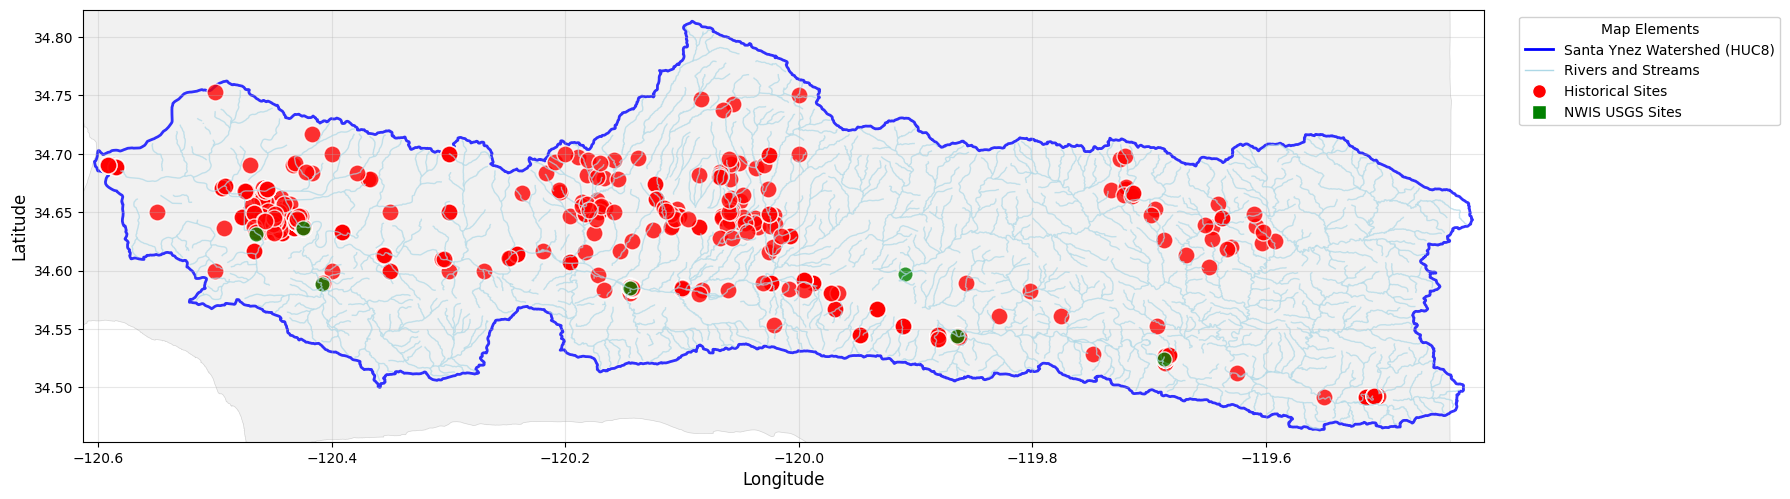


=== ANALYZING GAUGE SITE PROXIMITY TO STREAM ORDERS ===
Analyzing proximity of 714 gauge sites to streams...
Using stream order column: 'StreamOrderEdit'
Sites being analyzed:
  Historical: 707 sites
  NWIS USGS: 7 sites

=== STREAM ORDER PROXIMITY RESULTS ===
Total sites analyzed: 714

Sites by closest stream order:
  Stream Order 1: 99 sites
  Stream Order 2: 129 sites
  Stream Order 3: 44 sites
  Stream Order 4: 22 sites
  Stream Order 5: 420 sites

Sites by data type and closest stream order:
closest_stream_order   1    2   3   4    5
data_type                                 
Historical            99  128  44  20  416
NWIS USGS              0    1   0   2    4

Sites by decade and closest stream order:
closest_stream_order   1   2   3  4    5
decade                                  
1900                   5  14   0  1   35
1910                   3  15   0  0   10
1920                  14  14   2  4   59
1930                   1   7  18  2    8
1940                   8  21   4  5 

In [5]:
# ==== PART 2: SPATIAL FILTERING AND MAP CREATION ====
# This cell assumes the variables from Part 1 are available:
# combined_santa_ynez_gdf, rivers, huc8_watershed

# Define the stream order column name
stream_order_col = 'StreamOrderEdit'

# Verify the column exists in the rivers dataset
if rivers is not None:
    if stream_order_col in rivers.columns:
        print(f"✓ Using stream order column: '{stream_order_col}'")
    else:
        print(f"⚠ Column '{stream_order_col}' not found in rivers dataset")
        print("Available columns:", rivers.columns.tolist())
        stream_order_col = None

# Use combined_santa_ynez_gdf which includes both historical and NWIS sites
if 'combined_santa_ynez_gdf' in globals() and len(combined_santa_ynez_gdf) > 0:
    santa_ynez_gdf = combined_santa_ynez_gdf.copy()
    print(f"Using combined dataset with {len(santa_ynez_gdf)} sites")
    
    # Show breakdown by data type
    if 'data_type' in santa_ynez_gdf.columns:
        type_counts = santa_ynez_gdf['data_type'].value_counts()
        print(f"Sites by data type:")
        for dtype, count in type_counts.items():
            print(f"  {dtype}: {count} sites")
    
elif 'santa_ynez_gdf' in globals() and len(santa_ynez_gdf) > 0:
    print(f"Using historical sites only: {len(santa_ynez_gdf)} sites")
else:
    print("No Santa Ynez sites available for analysis")
    santa_ynez_gdf = gpd.GeoDataFrame()

if len(santa_ynez_gdf) > 0:
    
    # ==== FILTER SITES TO HUC BOUNDARY ====
    print(f"\n=== FILTERING SITES TO HUC BOUNDARY ===")
    
    # Perform spatial intersection to keep only sites within the HUC8 watershed
    if huc8_watershed is not None and len(santa_ynez_gdf) > 0:
        print(f"Sites before HUC filtering: {len(santa_ynez_gdf)}")
        
        # Ensure both datasets are in the same CRS
        if santa_ynez_gdf.crs != huc8_watershed.crs:
            print("Aligning coordinate systems...")
            if huc8_watershed.crs != "EPSG:4326":
                huc8_watershed = huc8_watershed.to_crs("EPSG:4326")
        
        # Clean up any existing index columns that might conflict
        if 'index_right' in santa_ynez_gdf.columns:
            santa_ynez_gdf = santa_ynez_gdf.drop(columns=['index_right'])
        if 'index_left' in santa_ynez_gdf.columns:
            santa_ynez_gdf = santa_ynez_gdf.drop(columns=['index_left'])
        if 'index_right' in huc8_watershed.columns:
            huc8_watershed = huc8_watershed.drop(columns=['index_right'])
        if 'index_left' in huc8_watershed.columns:
            huc8_watershed = huc8_watershed.drop(columns=['index_left'])
        
        # Perform spatial intersection - keep only points within the watershed
        santa_ynez_gdf_filtered = gpd.sjoin(santa_ynez_gdf, huc8_watershed, how='inner', predicate='within', lsuffix='_site', rsuffix='_watershed')
        
        # Remove duplicate columns created by the spatial join
        santa_ynez_gdf_filtered = santa_ynez_gdf_filtered.drop(columns=[col for col in santa_ynez_gdf_filtered.columns if col.endswith('_watershed')])
        
        print(f"Sites after HUC filtering: {len(santa_ynez_gdf_filtered)}")
        print(f"Removed {len(santa_ynez_gdf) - len(santa_ynez_gdf_filtered)} sites outside watershed boundary")
        
        # Update the geodataframe
        santa_ynez_gdf = santa_ynez_gdf_filtered
        
    else:
        if huc8_watershed is None:
            print("⚠ No HUC8 watershed available - cannot filter sites")
        if len(santa_ynez_gdf) == 0:
            print("⚠ No Santa Ynez sites to filter")
    
    # ==== CREATE ENHANCED MAP ====
    print(f"\n=== CREATING ENHANCED MAP ===")
    
    # Create single map: Santa Ynez sites colored by decade with watershed and rivers
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))  # Wider figure to accommodate side legend
    
    # Plot Santa Barbara County boundary (light background)
    if 'sb_county' in globals():
        sb_county.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)
    
    # Plot HUC8 watershed if available
    if huc8_watershed is not None:
        huc8_watershed.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=2, alpha=0.8, label='Santa Ynez Watershed (HUC8)')
    
    # Plot rivers if available
    if rivers is not None:
        rivers.plot(ax=ax, color='lightblue', linewidth=1, alpha=0.7, label='Rivers and Streams')
    
    # Plot sites - handle both data types if available
    legend_elements = []
    
    # Add watershed and rivers to legend if they exist
    if huc8_watershed is not None:
        legend_elements.append(Line2D([0], [0], color='blue', linewidth=2, label='Santa Ynez Watershed (HUC8)'))
    if rivers is not None:
        legend_elements.append(Line2D([0], [0], color='lightblue', linewidth=1, label='Rivers and Streams'))
    
    # Plot sites by data type if available
    if 'data_type' in santa_ynez_gdf.columns:
        # Define colors and markers for different data types
        data_type_styles = {
            'Historical': {'color': 'red', 'marker': 'o', 'size': 150},
            'NWIS USGS': {'color': 'green', 'marker': 's', 'size': 120}
        }
        
        for data_type in santa_ynez_gdf['data_type'].unique():
            type_sites = santa_ynez_gdf[santa_ynez_gdf['data_type'] == data_type]
            if len(type_sites) > 0:
                style = data_type_styles.get(data_type, {'color': 'blue', 'marker': 'o', 'size': 100})
                type_sites.plot(ax=ax, color=style['color'], markersize=style['size'], 
                              alpha=0.8, edgecolor='white', linewidth=1)
                
                # Add to legend
                legend_elements.append(Line2D([0], [0], marker=style['marker'], color='w', 
                                            markerfacecolor=style['color'], markersize=10, 
                                            label=f'{data_type} Sites', markeredgecolor='white'))
    
    # Fallback: Plot by decade if no data_type column or plot all in same color
    elif 'decade' in santa_ynez_gdf.columns:
        # Create color map for decades
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors = dict(zip(decades, colors))
        
        # Plot each decade separately
        for decade in decades:
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            decade_sites.plot(ax=ax, color=decade_colors[decade], markersize=150, 
                            alpha=0.9, label=f"{int(decade)}s", edgecolor='white', linewidth=1)
        
        # Add decade markers to legend
        for decade in decades:
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=decade_colors[decade], 
                                        markersize=12, label=f"{int(decade)}s", markeredgecolor='white'))
    else:
        # Plot all in same color if no decade info
        santa_ynez_gdf.plot(ax=ax, color='red', markersize=150, alpha=0.9, edgecolor='white', linewidth=1)
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                                    markersize=12, label='Santa Ynez River Sites', markeredgecolor='white'))
    
    # Place legend outside the plot area on the right
    ax.legend(handles=legend_elements, title='Map Elements', bbox_to_anchor=(1.02, 1), 
             loc='upper left', framealpha=0.9)
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    
    # Set extent based on watershed if available, otherwise use sites
    if huc8_watershed is not None:
        # Zoom to watershed extent with small buffer
        minx, miny, maxx, maxy = huc8_watershed.total_bounds
        buffer = 0.01
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    elif len(santa_ynez_gdf) > 0:
        # Zoom to sites extent with larger buffer
        minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
        buffer = 0.02
        ax.set_xlim(minx - buffer, maxx + buffer)
        ax.set_ylim(miny - buffer, maxy + buffer)
    
    # Add grid and improve appearance
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # ==== STREAM ORDER PROXIMITY ANALYSIS ====
    print(f"\n=== ANALYZING GAUGE SITE PROXIMITY TO STREAM ORDERS ===")
    
    if rivers is not None and stream_order_col is not None and len(santa_ynez_gdf) > 0:
        from shapely.geometry import Point
        
        print(f"Analyzing proximity of {len(santa_ynez_gdf)} gauge sites to streams...")
        print(f"Using stream order column: '{stream_order_col}'")
        
        # Show breakdown of sites being analyzed
        if 'data_type' in santa_ynez_gdf.columns:
            type_counts = santa_ynez_gdf['data_type'].value_counts()
            print(f"Sites being analyzed:")
            for dtype, count in type_counts.items():
                print(f"  {dtype}: {count} sites")
        
        # Create a list to store results
        proximity_results = []
        
        # For each gauge site, find the closest stream and its order
        for idx, site in santa_ynez_gdf.iterrows():
            site_point = site.geometry
            
            # Calculate distance to all stream segments
            min_distance = float('inf')
            closest_stream_order = None
            
            for stream_idx, stream in rivers.iterrows():
                stream_geom = stream.geometry
                if stream_geom is not None:
                    # Get the closest point on the stream to our site
                    try:
                        closest_point_on_stream = stream_geom.interpolate(stream_geom.project(site_point))
                        distance = site_point.distance(closest_point_on_stream)
                        
                        if distance < min_distance:
                            min_distance = distance
                            closest_stream_order = stream[stream_order_col]
                    except Exception as e:
                        # Skip problematic geometries
                        continue
            
            # Store the result
            result = {
                'site_index': idx,
                'site_id': site.get('site_id', site.get('station_id', 'Unknown')),
                'station_name': site.get('station_name', site.get('station_nm', site.get('site_nm', 'Unknown'))),
                'data_type': site.get('data_type', 'Unknown'),
                'decade': site.get('decade', 'Unknown'),
                'year_start': site.get('year_start', 'Unknown'),
                'year_end': site.get('year_end', 'Unknown'),
                'longitude': site_point.x,
                'latitude': site_point.y,
                'closest_stream_order': closest_stream_order,
                'distance_to_stream_km': min_distance * 111.32 if min_distance != float('inf') else None  # Convert degrees to km (approximate)
            }
            proximity_results.append(result)
        
        # Convert to DataFrame for analysis
        proximity_df = pd.DataFrame(proximity_results)
        import os

        # Save to a specific directory
        output_path = os.path.join('output', 'stream_proximity_results.csv')
        proximity_df.to_csv(output_path, index=False)
        
        # Display results
        print(f"\n=== STREAM ORDER PROXIMITY RESULTS ===")
        print(f"Total sites analyzed: {len(proximity_df)}")
        
        # Summary by stream order
        print(f"\nSites by closest stream order:")
        stream_order_summary = proximity_df['closest_stream_order'].value_counts().sort_index()
        for order, count in stream_order_summary.items():
            if pd.notna(order):
                print(f"  Stream Order {int(order)}: {count} sites")
        
        # Summary by data type and stream order
        if 'data_type' in proximity_df.columns:
            print(f"\nSites by data type and closest stream order:")
            try:
                data_type_stream_summary = proximity_df.groupby(['data_type', 'closest_stream_order']).size().unstack(fill_value=0)
                print(data_type_stream_summary)
            except Exception as e:
                print(f"Could not create data type summary: {e}")
        
        # Summary by decade and stream order
        if 'decade' in proximity_df.columns:
            print(f"\nSites by decade and closest stream order:")
            try:
                decade_stream_summary = proximity_df.groupby(['decade', 'closest_stream_order']).size().unstack(fill_value=0)
                print(decade_stream_summary)
            except Exception as e:
                print(f"Could not create decade summary: {e}")
        
        # Show sites with furthest distance from streams
        valid_distances = proximity_df[proximity_df['distance_to_stream_km'].notna()]
        if len(valid_distances) > 0:
            print(f"\nSites furthest from streams (top 5):")
            furthest_sites = valid_distances.nlargest(5, 'distance_to_stream_km')[
                ['station_name', 'data_type', 'decade', 'closest_stream_order', 'distance_to_stream_km']
            ]
            print(furthest_sites.to_string(index=False))
        
        # Show detailed results table
        print(f"\n=== DETAILED PROXIMITY RESULTS ===")
        display_columns = ['station_name', 'data_type', 'decade', 'year_start', 'year_end', 'closest_stream_order', 'distance_to_stream_km']
        available_columns = [col for col in display_columns if col in proximity_df.columns]
        
        # Sort by stream order, then by data type, then by decade
        proximity_display = proximity_df[available_columns].sort_values(['closest_stream_order', 'data_type', 'decade'])
        print(proximity_display.to_string(index=False))
        
        # Store results in a variable for further analysis
        globals()['stream_proximity_results'] = proximity_df
        print(f"\n✓ Results saved to 'stream_proximity_results' DataFrame")
        
    else:
        if rivers is None:
            print("⚠ No rivers data available for proximity analysis")
        elif stream_order_col is None:
            print("⚠ No stream order column found - cannot perform proximity analysis")
            if rivers is not None:
                print("Available columns in rivers dataset:", list(rivers.columns))
        elif len(santa_ynez_gdf) == 0:
            print("⚠ No gauge sites available for analysis")
    
    # ==== SUMMARY STATISTICS ====
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Total Santa Ynez River sites (within watershed): {len(santa_ynez_gdf)}")
    
    if len(santa_ynez_gdf) > 0:
        if 'data_type' in santa_ynez_gdf.columns:
            print(f"\nSites by data type:")
            data_type_summary = santa_ynez_gdf['data_type'].value_counts()
            for data_type, count in data_type_summary.items():
                print(f"  {data_type}: {count} sites")
        
        if 'decade' in santa_ynez_gdf.columns:
            print(f"\nSites by decade:")
            decade_summary = santa_ynez_gdf['decade'].value_counts().sort_index()
            for decade, count in decade_summary.items():
                if pd.notna(decade):
                    print(f"  {int(decade)}s: {count} sites")
        
        if 'data_source' in santa_ynez_gdf.columns:
            print(f"\nSites by data source:")
            source_summary = santa_ynez_gdf['data_source'].value_counts()
            for source, count in source_summary.items():
                print(f"  {source}: {count} sites")
        
        # Show coordinate bounds
        if len(santa_ynez_gdf) > 0:
            bounds = santa_ynez_gdf.total_bounds
            print(f"\nSpatial extent:")
            print(f"  Longitude: {bounds[0]:.4f} to {bounds[2]:.4f}")
            print(f"  Latitude: {bounds[1]:.4f} to {bounds[3]:.4f}")

else:
    print("No Santa Ynez River sites available for mapping.")

Geodatabase exists: True - C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb


C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Rivers loaded: 1653 features
✓ Lakes loaded:  132 features
Reprojecting rivers from EPSG:2229 -> EPSG:4326
Reprojecting lakes from EPSG:2229 -> EPSG:4326
Hydro data ready for mapping.
✓ Clipped to watershed: 34 lakes/wetlands within boundary
Stream orders found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]
Plotted 818 streams of order 1
Plotted 364 streams of order 2
Plotted 172 streams of order 3
Plotted 142 streams of order 4
Plotted 157 streams of order 5
✓ Plotted 34 lakes/wetlands on map


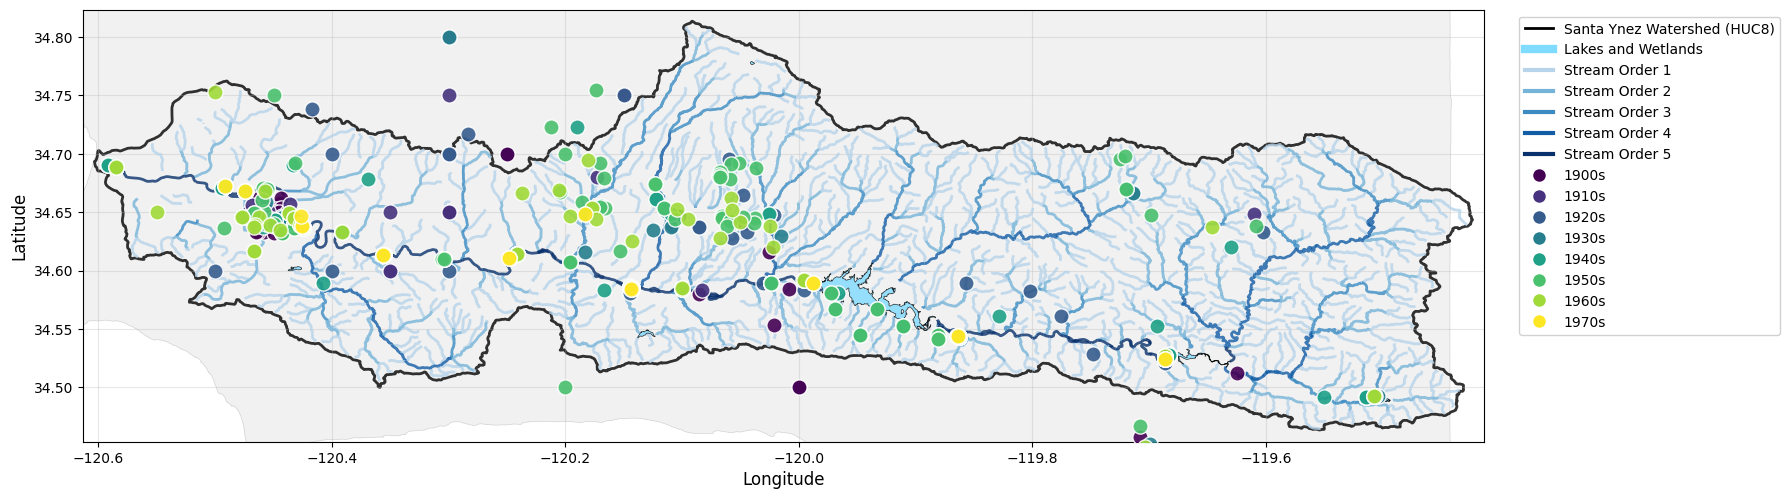


✓ Map created with 5 different stream orders
✓ Plotted 849 gauge sites
✓ Plotted 34 lakes and wetlands


In [3]:
# ==== STREAM ORDER COLORED MAP ====
# This creates a map with rivers colored by stream order and gauge sites colored by decade

import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import geopandas as gpd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------
gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb"

# Initialize
rivers = None
lakes  = None

# ---------------------------------------------------------------------
# Load rivers and lakes explicitly from the GDB
# ---------------------------------------------------------------------
gdb_exists = os.path.exists(gdb_path)
print(f"Geodatabase exists: {gdb_exists} - {gdb_path}")

try:
    if not gdb_exists:
        raise FileNotFoundError(f"GDB not found: {gdb_path}")

    # Exact layer names you provided
    rivers = gpd.read_file(gdb_path, layer="StreamsandRivers_Clip")
    lakes  = gpd.read_file(gdb_path, layer="LakesNationalWetlandsInventory_ExportFeatures")

    print(f"✓ Rivers loaded: {len(rivers)} features")
    print(f"✓ Lakes loaded:  {len(lakes)} features")

    # Normalize CRS to EPSG:4326 for consistency (only if defined)
    if rivers.crs is not None and str(rivers.crs) != "EPSG:4326":
        print(f"Reprojecting rivers from {rivers.crs} -> EPSG:4326")
        rivers = rivers.to_crs("EPSG:4326")
    if lakes.crs is not None and str(lakes.crs) != "EPSG:4326":
        print(f"Reprojecting lakes from {lakes.crs} -> EPSG:4326")
        lakes = lakes.to_crs("EPSG:4326")

    print("Hydro data ready for mapping.")

    # Optional: clip lakes to watershed if available
    if ('huc8_watershed' in globals()) and (huc8_watershed is not None) and (lakes is not None):
        if lakes.crs != huc8_watershed.crs:
            print("Converting lakes CRS to match watershed before clipping…")
            lakes = lakes.to_crs(huc8_watershed.crs)
        lakes_clipped = gpd.clip(lakes, huc8_watershed)
        print(f"✓ Clipped to watershed: {len(lakes_clipped)} lakes/wetlands within boundary")
        lakes = lakes_clipped if len(lakes_clipped) > 0 else None

except Exception as e:
    print(f"⚠ Error reading GDB layers: {e}")
    print("If needed, install dependencies: pip install fiona geopandas")
    rivers, lakes = None, None

# ---------------------------------------------------------------------
# Create enhanced map with stream order coloring
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

# Plot Santa Barbara County boundary (light background)
if 'sb_county' in globals() and sb_county is not None:
    sb_county.plot(ax=ax, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

# Plot HUC8 watershed boundary
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    huc8_watershed.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

# Plot rivers colored by stream order
stream_orders = []
order_colors = {}
if (rivers is not None) and ('StreamOrderEdit' in rivers.columns):
    stream_orders = sorted(rivers['StreamOrderEdit'].dropna().unique())
    print(f"Stream orders found: {stream_orders}")

    # Color ramp: darkest blue for highest order
    n_orders = len(stream_orders)
    blues_colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_orders))
    order_colors = {order: blues_colors[i] for i, order in enumerate(stream_orders)}

    for order in stream_orders:
        order_streams = rivers[rivers['StreamOrderEdit'] == order]
        if len(order_streams) > 0:
            order_streams.plot(ax=ax, color=order_colors[order], linewidth=2,
                               alpha=0.8, zorder=2)
            try:
                print(f"Plotted {len(order_streams)} streams of order {int(order)}")
            except Exception:
                print(f"Plotted {len(order_streams)} streams of order {order}")

# Plot lakes (after rivers so they’re visible)
if lakes is not None and len(lakes) > 0:
    lakes.plot(ax=ax,
               facecolor='#7FDBFF',   # readable cyan fill
               edgecolor='black',     # outline so they pop over rivers
               linewidth=0.5,
               alpha=0.8,
               zorder=6)
    print(f"✓ Plotted {len(lakes)} lakes/wetlands on map")

# Plot Santa Ynez gauge sites colored by decade
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        decade_colors_map = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors = dict(zip(decades, decade_colors_map))

        for decade in decades:
            decade_sites = santa_ynez_gdf[santa_ynez_gdf['decade'] == decade]
            decade_sites.plot(ax=ax, color=decade_colors[decade], markersize=120,
                              alpha=0.9, edgecolor='white', linewidth=1, zorder=7)
    else:
        santa_ynez_gdf.plot(ax=ax, color='red', markersize=120, alpha=0.9,
                            edgecolor='white', linewidth=1, zorder=7)

# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------
legend_elements = []

# Watershed
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    legend_elements.append(Line2D([0], [0], color='black', linewidth=2,
                                  label='Santa Ynez Watershed (HUC8)'))

# Lakes
if lakes is not None and len(lakes) > 0:
    legend_elements.append(Line2D([0], [0], color='#7FDBFF', linewidth=6,
                                  label='Lakes and Wetlands'))

# Stream orders
if (rivers is not None) and ('StreamOrderEdit' in rivers.columns) and stream_orders:
    for order in stream_orders:
        legend_elements.append(Line2D([0], [0], color=order_colors[order], linewidth=3,
                                      label=f'Stream Order {int(order)}' if isinstance(order, (int, np.integer, float)) else f'Stream Order {order}'))

# Gauge site decades
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        for decade in decades:
            legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=decade_colors[decade],
                                          markersize=10, label=f"{int(decade)}s",
                                          markeredgecolor='white'))
    else:
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                      markerfacecolor='red', markersize=10,
                                      label='Gauge Sites', markeredgecolor='white'))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1),
          loc='upper left', framealpha=0.9, fontsize=10)

# ---------------------------------------------------------------------
# Axes, extent, layout
# ---------------------------------------------------------------------
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Extent from watershed, else sites
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    minx, miny, maxx, maxy = huc8_watershed.total_bounds
    buffer = 0.01
    ax.set_xlim(minx - buffer, maxx + buffer)
    ax.set_ylim(miny - buffer, maxy + buffer)
elif 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
    buffer = 0.02
    ax.set_xlim(minx - buffer, maxx + buffer)
    ax.set_ylim(miny - buffer, maxy + buffer)

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots\streamorder_map.png",
            dpi=300, bbox_inches="tight")

plt.show()

print(f"\n✓ Map created with {len(stream_orders) if stream_orders else 0} different stream orders")
if 'santa_ynez_gdf' in globals():
    print(f"✓ Plotted {len(santa_ynez_gdf)} gauge sites")
if lakes is not None and len(lakes) > 0:
    print(f"✓ Plotted {len(lakes)} lakes and wetlands")


Historical sites: 612
NWIS sites: 7
Historical data range: 1903 - 1978
NWIS data range: 1952 - 1973
Geodatabase exists: True - C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb


C:\Users\aeliz\miniforge3\envs\hydro\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


✓ Rivers loaded: 1653 features
✓ Lakes loaded:  132 features
Reprojecting rivers from EPSG:2229 -> EPSG:4326
Reprojecting lakes from EPSG:2229 -> EPSG:4326
Stream orders found: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)]


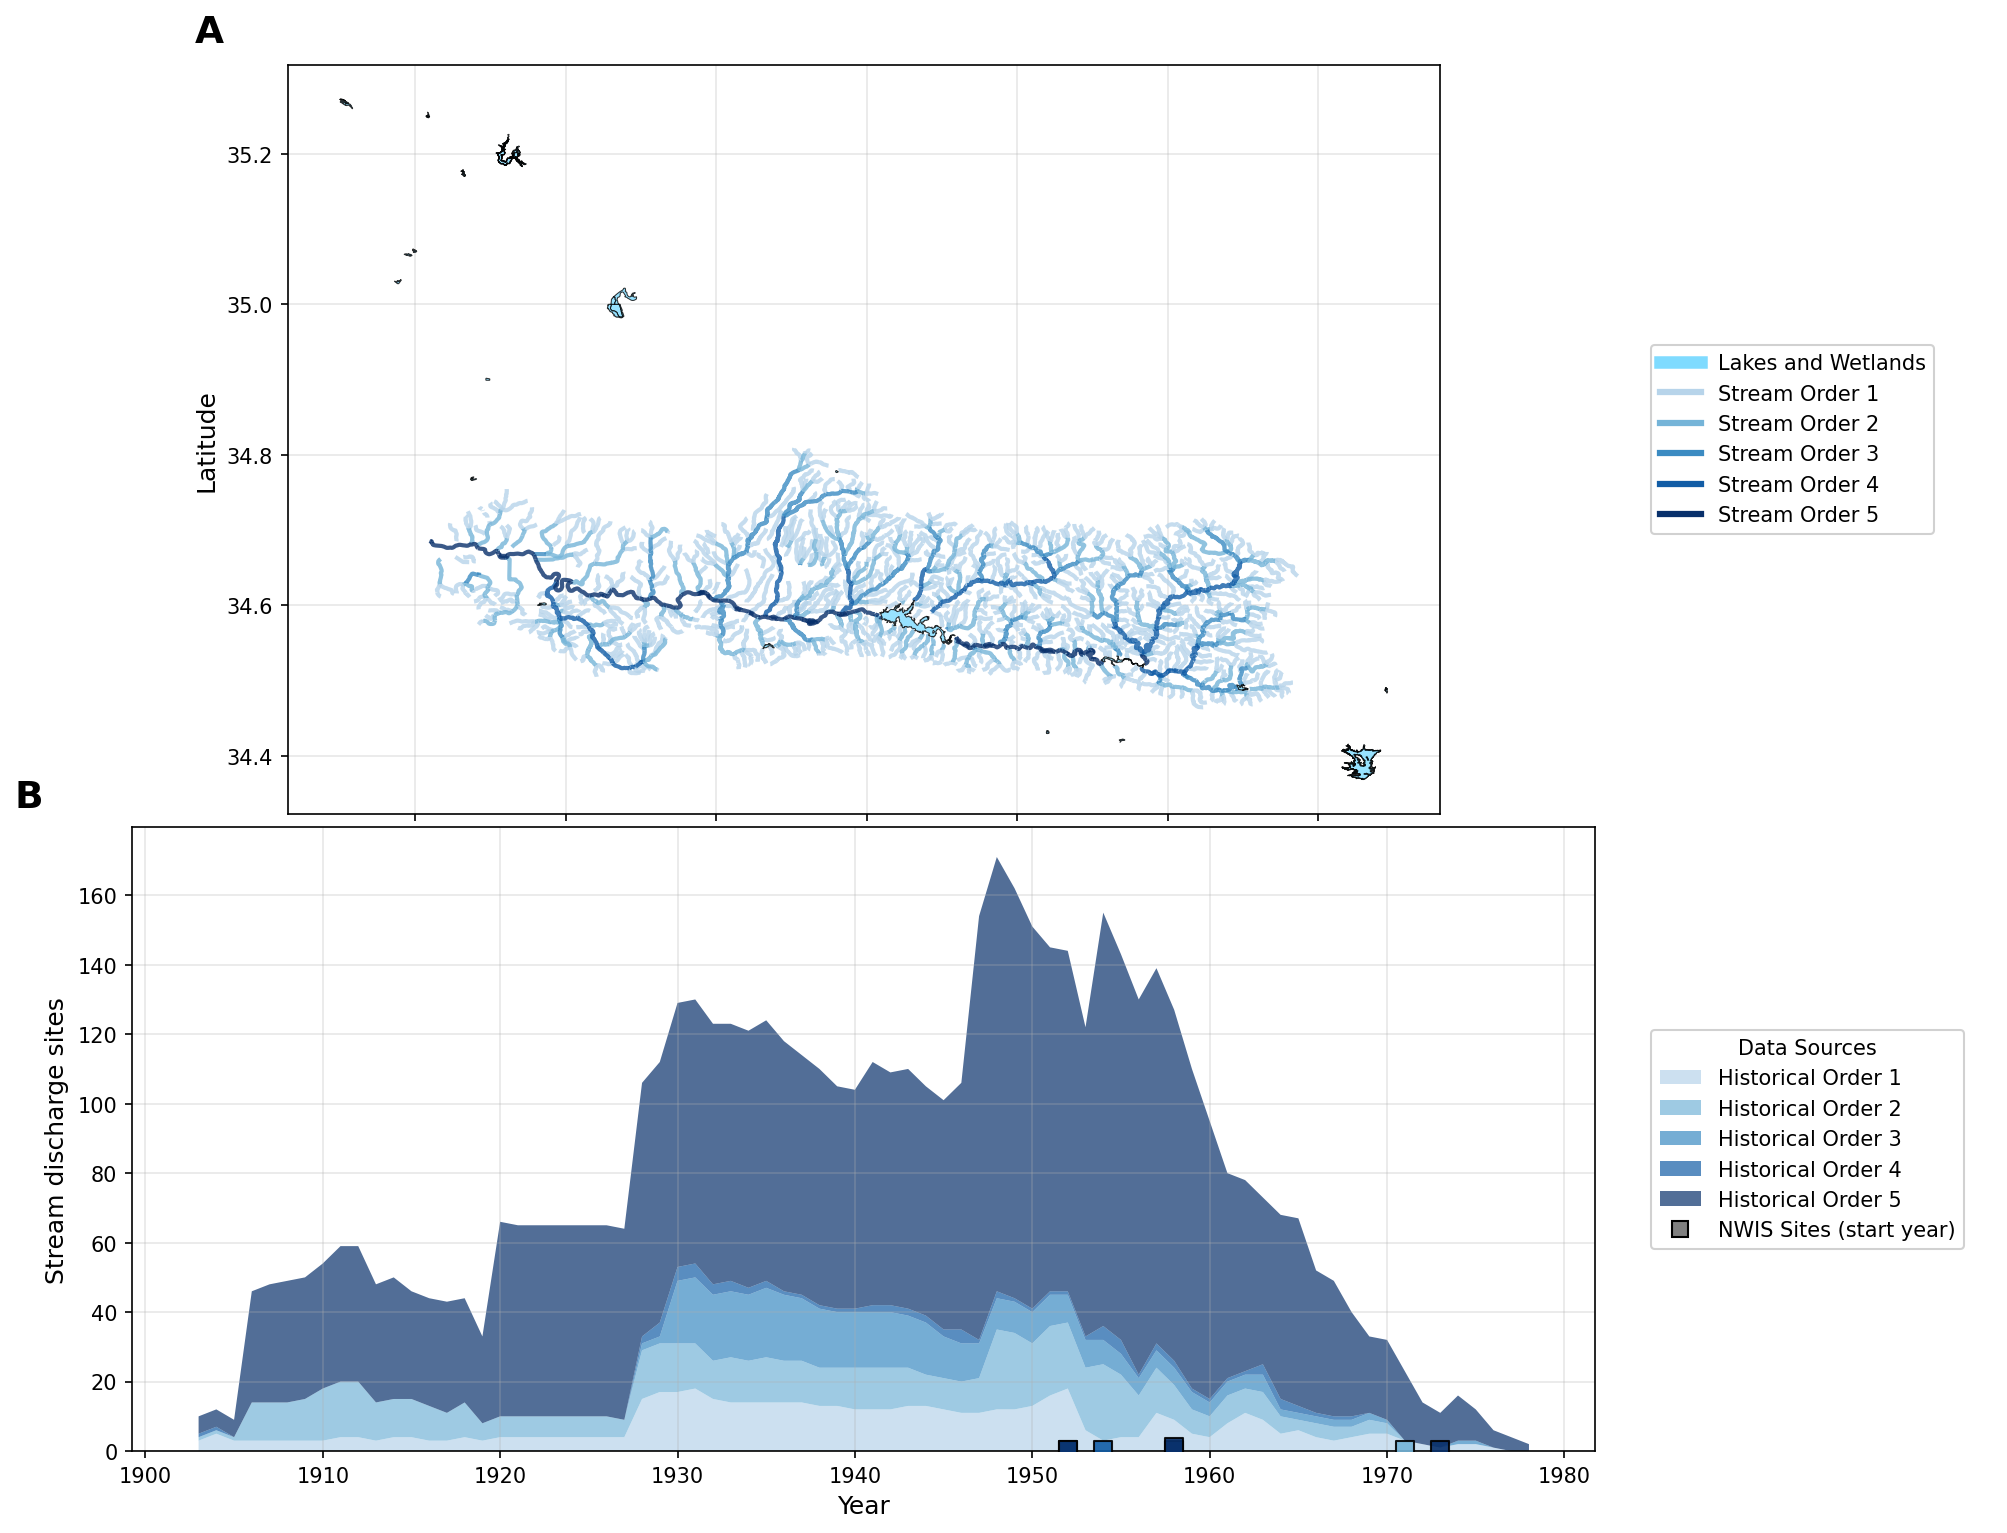


✓ Combined Historical + NWIS figure created!
✓ Map with 5 different stream orders
✓ Map plotted 132 lakes and wetlands
✓ Timeline shows historical data from 1903 to 1978
✓ Timeline shows 7 NWIS sites established 1952-1973


In [1]:
# === COMBINED FIGURE: Stream Order Map (Panel A) + Timeline (Panel B) ===
# Modified to include both Historical and NWIS sites
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from matplotlib.lines import Line2D
from collections import defaultdict

# ------------------------------------------------------------
# 1) Load the results DataFrame for timeline
# ------------------------------------------------------------
if 'stream_proximity_results' not in globals():
    results_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\stream_proximity_results.csv"
    stream_proximity_results = pd.read_csv(results_path)

df = stream_proximity_results.copy()

# Separate historical and NWIS data
historical_df = df[df['data_type'] == 'Historical'].copy()
nwis_df = df[df['data_type'] == 'NWIS USGS'].copy()

# Process historical data for timeline
historical_df['year_start'] = pd.to_numeric(historical_df['year_start'], errors='coerce')
historical_df['year_end']   = pd.to_numeric(historical_df['year_end'], errors='coerce')
historical_df['closest_stream_order'] = pd.to_numeric(historical_df['closest_stream_order'], errors='coerce')
historical_df = historical_df.dropna(subset=['year_start', 'year_end', 'closest_stream_order'])
historical_df['year_start'] = historical_df['year_start'].astype(int)
historical_df['year_end']   = historical_df['year_end'].astype(int)
historical_df['closest_stream_order'] = historical_df['closest_stream_order'].astype(int)

# Process NWIS data for timeline (they have start_year instead of year ranges)
nwis_df['start_year'] = pd.to_numeric(nwis_df['start_year'], errors='coerce')
nwis_df['closest_stream_order'] = pd.to_numeric(nwis_df['closest_stream_order'], errors='coerce')
nwis_df = nwis_df.dropna(subset=['start_year', 'closest_stream_order'])
nwis_df['start_year'] = nwis_df['start_year'].astype(int)
nwis_df['closest_stream_order'] = nwis_df['closest_stream_order'].astype(int)

print(f"Historical sites: {len(historical_df)}")
print(f"NWIS sites: {len(nwis_df)}")

# Check the temporal range of both datasets
if len(historical_df) > 0:
    hist_min = historical_df['year_start'].min()
    hist_max = historical_df['year_end'].max()
    print(f"Historical data range: {hist_min} - {hist_max}")

if len(nwis_df) > 0:
    nwis_min = nwis_df['start_year'].min()
    nwis_max = nwis_df['start_year'].max()
    print(f"NWIS data range: {nwis_min} - {nwis_max}")

# ------------------------------------------------------------
# 2) Load geographic data for map
# ------------------------------------------------------------
gdb_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\data\lakes\chap2map.gdb"
rivers = None
lakes  = None

gdb_exists = os.path.exists(gdb_path)
print(f"Geodatabase exists: {gdb_exists} - {gdb_path}")

try:
    if not gdb_exists:
        raise FileNotFoundError(f"GDB not found: {gdb_path}")

    rivers = gpd.read_file(gdb_path, layer="StreamsandRivers_Clip")
    lakes  = gpd.read_file(gdb_path, layer="LakesNationalWetlandsInventory_ExportFeatures")

    print(f"✓ Rivers loaded: {len(rivers)} features")
    print(f"✓ Lakes loaded:  {len(lakes)} features")

    if rivers.crs is not None and str(rivers.crs) != "EPSG:4326":
        print(f"Reprojecting rivers from {rivers.crs} -> EPSG:4326")
        rivers = rivers.to_crs("EPSG:4326")
    if lakes.crs is not None and str(lakes.crs) != "EPSG:4326":
        print(f"Reprojecting lakes from {lakes.crs} -> EPSG:4326")
        lakes = lakes.to_crs("EPSG:4326")

    if ('huc8_watershed' in globals()) and (huc8_watershed is not None) and (lakes is not None):
        if lakes.crs != huc8_watershed.crs:
            print("Converting lakes CRS to match watershed before clipping…")
            lakes = lakes.to_crs(huc8_watershed.crs)
        lakes_clipped = gpd.clip(lakes, huc8_watershed)
        print(f"✓ Clipped to watershed: {len(lakes_clipped)} lakes/wetlands within boundary")
        lakes = lakes_clipped if len(lakes_clipped) > 0 else None

except Exception as e:
    print(f"⚠ Error reading GDB layers: {e}")
    rivers, lakes = None, None

# ------------------------------------------------------------
# 3) Build timeline data (historical only for stacked area)
# ------------------------------------------------------------
counts = defaultdict(int)
for _, row in historical_df.iterrows():
    ys, ye, order = row['year_start'], row['year_end'], row['closest_stream_order']
    if ys > ye:
        ys, ye = ye, ys
    for y in range(ys, ye + 1):
        counts[(y, order)] += 1

if counts:
    idx = pd.MultiIndex.from_tuples(counts.keys(), names=['year', 'closest_stream_order'])
    timeline = pd.Series(counts, index=idx).sort_index().rename('count').reset_index()
    pvt_t = timeline.pivot(index='year', columns='closest_stream_order', values='count').fillna(0).astype(int)
else:
    pvt_t = pd.DataFrame()

# ------------------------------------------------------------
# 4) Set up consistent color schemes
# ------------------------------------------------------------
stream_orders = []
stream_order_colors = {}

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns):
    stream_orders = sorted(rivers['StreamOrderEdit'].dropna().unique())
    print(f"Stream orders found: {stream_orders}")

if not pvt_t.empty:
    timeline_orders = sorted(pvt_t.columns.tolist())
    if timeline_orders:
        stream_orders = timeline_orders

if stream_orders:
    n_orders = len(stream_orders)
    blues_colors = plt.cm.Blues(np.linspace(0.3, 1.0, n_orders))
    stream_order_colors = {order: blues_colors[i] for i, order in enumerate(stream_orders)}

# Colors for different data types and decades
decade_colors_map = {}
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    if 'decade' in santa_ynez_gdf.columns:
        decades = sorted(santa_ynez_gdf['decade'].dropna().unique())
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(decades)))
        decade_colors_map = dict(zip(decades, viridis_colors))

# ------------------------------------------------------------
# 5) Create combined figure (tight vertical spacing, no panel titles)
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12), dpi=150)

# Minimal vertical space between panels
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[5, 1.2],
    height_ratios=[1.2, 1],
    hspace=0.02,
    wspace=0.05
)

# =========================
# PANEL A - MAP (top left)
# =========================
ax_map = fig.add_subplot(gs[0, 0])

if 'sb_county' in globals() and sb_county is not None:
    sb_county.plot(ax=ax_map, color='lightgray', alpha=0.3, edgecolor='gray', linewidth=0.5)

if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    huc8_watershed.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=2, alpha=0.8)

if (rivers is not None) and ('StreamOrderEdit' in rivers.columns) and stream_orders:
    for order in stream_orders:
        if order in stream_order_colors:
            order_streams = rivers[rivers['StreamOrderEdit'] == order]
            if len(order_streams) > 0:
                order_streams.plot(ax=ax_map, color=stream_order_colors[order], linewidth=2, alpha=0.8, zorder=2)

if lakes is not None and len(lakes) > 0:
    lakes.plot(ax=ax_map, facecolor='#7FDBFF', edgecolor='black', linewidth=0.5, alpha=0.8, zorder=6)

# Plot historical sites (by decade)
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    historical_sites = santa_ynez_gdf[santa_ynez_gdf.get('data_type', 'Historical') == 'Historical']
    if len(historical_sites) > 0:
        if 'decade' in historical_sites.columns and decade_colors_map:
            for decade in decade_colors_map.keys():
                decade_sites = historical_sites[historical_sites['decade'] == decade]
                if len(decade_sites) > 0:
                    decade_sites.plot(ax=ax_map, color=decade_colors_map[decade], markersize=120,
                                      alpha=0.9, edgecolor='white', linewidth=1, zorder=7)
        else:
            historical_sites.plot(ax=ax_map, color='red', markersize=120, alpha=0.9,
                                edgecolor='white', linewidth=1, zorder=7)

# Plot NWIS sites on top (different marker and color)
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    nwis_sites = santa_ynez_gdf[santa_ynez_gdf.get('data_type', '') == 'NWIS USGS']
    if len(nwis_sites) > 0:
        nwis_sites.plot(ax=ax_map, color='orange', marker='s', markersize=150,
                       alpha=0.95, edgecolor='black', linewidth=2, zorder=8)

# Axes labels, no title
ax_map.set_xlabel('Longitude', fontsize=12)
ax_map.set_ylabel('Latitude', fontsize=12)

# Extent
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    minx, miny, maxx, maxy = huc8_watershed.total_bounds
    buffer = 0.01
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)
elif 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    minx, miny, maxx, maxy = santa_ynez_gdf.total_bounds
    buffer = 0.02
    ax_map.set_xlim(minx - buffer, maxx + buffer)
    ax_map.set_ylim(miny - buffer, maxy + buffer)

ax_map.grid(True, alpha=0.3)
ax_map.set_aspect('equal')

# Panel label "A" at far-left top
ax_map.text(-0.08, 1.02, "A", transform=ax_map.transAxes,
            fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# MAP LEGEND (top right)
# =========================
ax_map_legend = fig.add_subplot(gs[0, 1])
ax_map_legend.axis('off')

legend_elements_map = []
if 'huc8_watershed' in globals() and (huc8_watershed is not None):
    legend_elements_map.append(Line2D([0], [0], color='black', linewidth=2, label='Santa Ynez Watershed'))
if lakes is not None and len(lakes) > 0:
    legend_elements_map.append(Line2D([0], [0], color='#7FDBFF', linewidth=6, label='Lakes and Wetlands'))
if stream_orders and stream_order_colors:
    for order in stream_orders:
        legend_elements_map.append(Line2D([0], [0], color=stream_order_colors[order], linewidth=3,
                                          label=f'Stream Order {int(order)}'))

# Add historical sites legend (by decade if available)
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    historical_sites = santa_ynez_gdf[santa_ynez_gdf.get('data_type', 'Historical') == 'Historical']
    if len(historical_sites) > 0:
        if decade_colors_map:
            for decade in sorted(decade_colors_map.keys()):
                legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                                  markerfacecolor=decade_colors_map[decade],
                                                  markersize=10, label=f"Historical {int(decade)}s",
                                                  markeredgecolor='white'))
        else:
            legend_elements_map.append(Line2D([0], [0], marker='o', color='w',
                                              markerfacecolor='red', markersize=10,
                                              label='Historical Sites', markeredgecolor='white'))

# Add NWIS sites legend
if 'santa_ynez_gdf' in globals() and (len(santa_ynez_gdf) > 0):
    nwis_sites = santa_ynez_gdf[santa_ynez_gdf.get('data_type', '') == 'NWIS USGS']
    if len(nwis_sites) > 0:
        legend_elements_map.append(Line2D([0], [0], marker='s', color='w',
                                          markerfacecolor='orange', markersize=10,
                                          label='NWIS Sites', markeredgecolor='black'))

if legend_elements_map:
    ax_map_legend.legend(handles=legend_elements_map, loc='center left',
                         bbox_to_anchor=(0, 0.5), framealpha=0.9, fontsize=10)

# =========================
# PANEL B - TIMELINE (bottom left)
# =========================
ax_timeline = fig.add_subplot(gs[1, 0])

# Historical timeline (stacked area)
if not pvt_t.empty and stream_order_colors:
    years = pvt_t.index.values
    orders_sorted = sorted(pvt_t.columns.tolist())
    y_stacks = [pvt_t[o].values for o in orders_sorted]
    ax_timeline.stackplot(years, y_stacks,
                          labels=[f'Historical Order {int(o)}' for o in orders_sorted],
                          colors=[stream_order_colors[o] for o in orders_sorted],
                          alpha=0.7)

# Add NWIS sites to timeline (they have specific start years)
if len(nwis_df) > 0:
    # Count NWIS sites by start year and stream order
    nwis_counts_by_year = nwis_df.groupby(['start_year', 'closest_stream_order']).size().reset_index(name='count')
    
    # Add NWIS markers to the timeline
    for _, row in nwis_counts_by_year.iterrows():
        year, order, count = row['start_year'], row['closest_stream_order'], row['count']
        if order in stream_order_colors:
            # Stack markers vertically for multiple sites in the same year/order
            y_positions = [i + 0.2 for i in range(count)]  # Slight offset from bottom
            ax_timeline.scatter([year] * count, y_positions,
                               color=stream_order_colors[order], marker='s', s=80,
                               edgecolor='black', linewidth=1, alpha=0.9, zorder=10)

ax_timeline.set_xlabel("Year", fontsize=12)
ax_timeline.set_ylabel("Stream discharge sites", fontsize=12)
ax_timeline.grid(True, alpha=0.3)

# Panel label "B" at far-left top
ax_timeline.text(-0.08, 1.02, "B", transform=ax_timeline.transAxes,
                 fontsize=18, fontweight='bold', ha='left', va='bottom', clip_on=False)

# =========================
# TIMELINE LEGEND (bottom right)
# =========================
ax_timeline_legend = fig.add_subplot(gs[1, 1])
ax_timeline_legend.axis('off')

legend_elements_timeline = []

# Historical data legend
if not pvt_t.empty and stream_order_colors:
    orders_sorted = sorted(pvt_t.columns.tolist())
    for order in orders_sorted:
        legend_elements_timeline.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=stream_order_colors[order], alpha=0.7, 
                         label=f'Historical Order {int(order)}')
        )

# NWIS data legend
if len(nwis_df) > 0:
    legend_elements_timeline.append(
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray',
               markersize=8, label='NWIS Sites (start year)', markeredgecolor='black')
    )

if legend_elements_timeline:
    ax_timeline_legend.legend(handles=legend_elements_timeline, title="Data Sources",
                              loc='center left', bbox_to_anchor=(0, 0.5),
                              framealpha=0.9, fontsize=10)

# ------------------------------------------------------------
# 6) Save the combined figure
# ------------------------------------------------------------
outdir = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\plots"
os.makedirs(outdir, exist_ok=True)

plt.savefig(os.path.join(outdir, "combined_historical_nwis_figure3.png"),
            dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Combined Historical + NWIS figure created!")
print(f"✓ Map with {len(stream_orders) if stream_orders else 0} different stream orders")
if 'santa_ynez_gdf' in globals():
    historical_count = len(santa_ynez_gdf[santa_ynez_gdf.get('data_type', 'Historical') == 'Historical'])
    nwis_count = len(santa_ynez_gdf[santa_ynez_gdf.get('data_type', '') == 'NWIS USGS'])
    print(f"✓ Map plotted {historical_count} historical sites and {nwis_count} NWIS sites")
if lakes is not None and len(lakes) > 0:
    print(f"✓ Map plotted {len(lakes)} lakes and wetlands")
if not pvt_t.empty:
    print(f"✓ Timeline shows historical data from {pvt_t.index.min()} to {pvt_t.index.max()}")
if len(nwis_df) > 0:
    print(f"✓ Timeline shows {len(nwis_df)} NWIS sites established {nwis_df['start_year'].min()}-{nwis_df['start_year'].max()}")

In [17]:
# Code to thoroughly examine your original NWIS data structure
# Add this early in your script, right after loading the results CSV

print("="*60)
print("EXAMINING ORIGINAL NWIS DATA STRUCTURE")
print("="*60)

# Load the original results file
results_path = r"C:\Users\aeliz\Dropbox\Documents\Jupyter Notebooks\chap2_usgs\output\stream_proximity_results.csv"
original_df = pd.read_csv(results_path)

print(f"Original DataFrame shape: {original_df.shape}")
print(f"Total rows: {len(original_df)}")

# Check data types breakdown
data_type_counts = original_df['data_type'].value_counts()
print(f"\nData type breakdown:")
for dtype, count in data_type_counts.items():
    print(f"  {dtype}: {count} rows")

print(f"\nAll columns in original data:")
for i, col in enumerate(original_df.columns):
    print(f"  {i+1:2d}. {col}")

print(f"\nColumn data types:")
for col, dtype in original_df.dtypes.items():
    print(f"  {col:<25} {dtype}")

# Focus on NWIS data specifically
print("\n" + "="*40)
print("NWIS DATA DETAILED ANALYSIS")
print("="*40)

nwis_original = original_df[original_df['data_type'] == 'NWIS USGS'].copy()
print(f"NWIS rows: {len(nwis_original)}")

if len(nwis_original) > 0:
    print(f"\nFirst 3 NWIS rows (all columns):")
    print(nwis_original.head(3).to_string())
    
    # Check each column for missing values in NWIS data
    print(f"\nMissing value analysis for NWIS data:")
    for col in nwis_original.columns:
        missing_count = nwis_original[col].isna().sum()
        missing_pct = (missing_count / len(nwis_original)) * 100
        unique_vals = nwis_original[col].nunique()
        print(f"  {col:<25} Missing: {missing_count:3d}/{len(nwis_original)} ({missing_pct:5.1f}%) | Unique values: {unique_vals}")
    
    # Look at unique values in key columns
    key_columns = ['year_start', 'year_end', 'decade', 'site_id', 'station_name']
    for col in key_columns:
        if col in nwis_original.columns:
            unique_vals = nwis_original[col].unique()
            print(f"\nUnique values in '{col}':")
            if len(unique_vals) <= 10:
                for val in unique_vals:
                    count = (nwis_original[col] == val).sum()
                    print(f"  '{val}': {count} occurrences")
            else:
                print(f"  Too many unique values ({len(unique_vals)}). First 10:")
                for val in unique_vals[:10]:
                    count = (nwis_original[col] == val).sum()
                    print(f"    '{val}': {count} occurrences")
    
    # Check if there are any non-null year values
    print(f"\n" + "="*40)
    print("YEAR DATA INVESTIGATION")
    print("="*40)
    
    if 'year_start' in nwis_original.columns:
        non_null_year_start = nwis_original['year_start'].dropna()
        print(f"Non-null year_start values: {len(non_null_year_start)}")
        if len(non_null_year_start) > 0:
            print(f"Year start range: {non_null_year_start.min()} to {non_null_year_start.max()}")
            print(f"Sample year_start values: {non_null_year_start.head().tolist()}")
    
    if 'year_end' in nwis_original.columns:
        non_null_year_end = nwis_original['year_end'].dropna()
        print(f"Non-null year_end values: {len(non_null_year_end)}")
        if len(non_null_year_end) > 0:
            print(f"Year end range: {non_null_year_end.min()} to {non_null_year_end.max()}")
            print(f"Sample year_end values: {non_null_year_end.head().tolist()}")
    
    # Check for any date-related columns
    date_cols = [col for col in nwis_original.columns if any(word in col.lower() for word in ['date', 'time', 'start', 'end', 'begin'])]
    if date_cols:
        print(f"\nFound date-related columns: {date_cols}")
        for col in date_cols:
            sample_vals = nwis_original[col].dropna().head(3).tolist()
            print(f"  {col}: sample values = {sample_vals}")

else:
    print("No NWIS data found!")

# Check if there might be other data sources with year information
print(f"\n" + "="*40)
print("OTHER DATA TYPES YEAR INFO")
print("="*40)

for dtype in original_df['data_type'].unique():
    if dtype != 'NWIS USGS':
        subset = original_df[original_df['data_type'] == dtype]
        if 'year_start' in subset.columns:
            non_null_years = subset['year_start'].dropna()
            print(f"{dtype}: {len(non_null_years)} sites with year_start data")
            if len(non_null_years) > 0:
                print(f"  Range: {non_null_years.min()} to {non_null_years.max()}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

EXAMINING ORIGINAL NWIS DATA STRUCTURE
Original DataFrame shape: (714, 15)
Total rows: 714

Data type breakdown:
  Historical: 707 rows
  NWIS USGS: 7 rows

All columns in original data:
   1. site_index
   2. site_id
   3. station_name
   4. data_type
   5. start_year
   6. end_year
   7. year_start
   8. year_end
   9. decade_start
  10. decade_end
  11. decade
  12. closest_stream_order
  13. distance_to_stream_km
  14. longitude
  15. latitude

Column data types:
  site_index                int64
  site_id                   float64
  station_name              object
  data_type                 object
  start_year                float64
  end_year                  float64
  year_start                float64
  year_end                  float64
  decade_start              float64
  decade_end                float64
  decade                    float64
  closest_stream_order      int64
  distance_to_stream_km     float64
  longitude                 float64
  latitude                  fl